# Actividad4
## Objetivo

Reforzar los conocimientos sobre regresión lineal múltiple y regresión logística binaria para analizar datos y generar predicciones útiles en contextos de toma de decisiones.

### Parte 1: 
Predicción de ventas usando regresión lineal múltiple En esta sección de la actividad, crearás y evaluarás un modelo de regresión lineal múltiple para predecir las ventas de los vehículos de acuerdo con el precio de venta establecido y el kilometraje de los mismos.

1. **Preparación de los datos:** Guarda la base de datos en una variable. Los datos los obtendrás de la siguiente liga: https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data/download? datasetVersionNumber=1

In [1]:
import pandas as pd

# Carga de datos
df = pd.read_csv('car_prices.csv') 

# Ver primeras filas
print(df.head())


   year   make                model        trim   body transmission  \
0  2015    Kia              Sorento          LX    SUV    automatic   
1  2015    Kia              Sorento          LX    SUV    automatic   
2  2014    BMW             3 Series  328i SULEV  Sedan    automatic   
3  2015  Volvo                  S60          T5  Sedan    automatic   
4  2014    BMW  6 Series Gran Coupe        650i  Sedan    automatic   

                 vin state  condition  odometer  color interior  \
0  5xyktca69fg566472    ca        5.0   16639.0  white    black   
1  5xyktca69fg561319    ca        5.0    9393.0  white    beige   
2  wba3c1c51ek116351    ca       45.0    1331.0   gray    black   
3  yv1612tb4f1310987    ca       41.0   14282.0  white    black   
4  wba6b2c57ed129731    ca       43.0    2641.0   gray    black   

                                   seller      mmr  sellingprice  \
0                 kia motors america  inc  20500.0       21500.0   
1                 kia motors ameri

2. **Análisis exploratorio:** Realiza una gráfica de dispersión para verificar la relación que existe entre el precio, el kilometraje y las ventas. Para esto, utiliza pairplot de la biblioteca Seaborn, la cual te permitirá visualizar las relaciones entre estas variables.

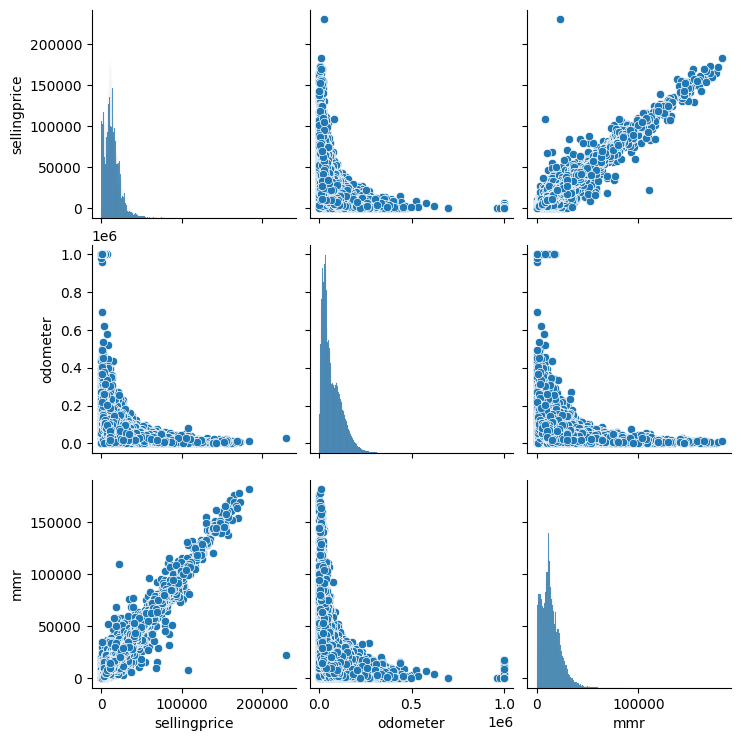

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df[['sellingprice', 'odometer', 'mmr']])  
plt.show()

3. **Identificación de variables:** Determina cuáles son las variables independientes y cuál es la dependiente.

### Variables dependientes:

La variable de ventas es dependientes porque representa el resultado del comoportamineto del mercado. Esta variable esta influenciada por diversos factores como el precio del vehiculo, el kilometraje, la antigüedad, la marca y el estado general de lo que es el carro, osea, las ventas no son una caracterisitca propia del vehiculo, si no un resultado del como los compradores perciben el valor en función de estas variables.

### Variables indpendientes:

Las variables independientes en este modelo son el precio y el kilometraje, ya que representan caractersitcas propias del vehiculo que influyen directamente en la decision de compra de los clientes. El precio afecta accesibilidad del carro, mientras que el kilometraje se refleja la calidad de uso y desgaste, por otro lado, como vimos la variable dependiente es el nivel de ventas, ya que este depende del impacto de estas dos variables.

### Resumidamente 

Las ventas son una consecuencia del valor visto o tachado por parte del mercado, el cual esta determinado por las variables tanto como el precio y el kilometraje.

In [ ]:
df = df[['sellingprice', 'odometer', 'mmr']] # Es como una filtro que nos permite seguir con nuestro modelo evitando valores no deseados.
df = df.dropna() # Elimina Valores nulos

4. **División de datos:** Crea los grupos de entrenamiento y de prueba para tus variables. Esta división es esencial para entrenar tu modelo con un conjunto de datos y evaluar su rendimiento con otro, asegurando así que el modelo sea capaz de generalizar a nuevos datos.

In [8]:
from sklearn.model_selection import train_test_split

X = df[['sellingprice', 'odometer']]
y = df['mmr']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

5. **Modelado:** Aplica el modelo de regresión lineal múltiple.

In [ ]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_train, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


6. **Evaluación del modelo:** Puedes utilizar métricas como el R² (coeficiente de determinación) para entender qué tan bien el modelo se ajusta a los datos.

In [10]:
r2 = modelo.score(X_test, y_test)
print("R²:", r2)

R²: 0.9689458620267114


### Valor R²

Como podemos ver nos dío como resultado 0.9689, lo que este modelo explica aproximadamente el 96.89% de los datos, esto quiere decir que el mode tiene un buen ajuste, pero, este valor tan alto puede deberse a que el precio de venta y el valor del carro estan muy relacionados entre sí.

7. **Predicción:** Con el modelo ya entrenado y evaluado, procede a realizar las predicciones.

In [17]:
y_pred = modelo.predict(X_test)

print(y_pred[:5])

[11570.89462737 16954.84022792 13640.01736256  5153.44911324
 17624.48144913]


En esta parte se generó predicciones utilizando el modelo entrenado a partir de los datos de prueba. Los valores obtenidos representan estimaciones del valor del carro, basadas en el precio y el kilometraje 

8. **Error cuadrático medio:** Este paso te ayudará a entender la magnitud de los errores cometidos por el modelo en sus predicciones.

In [18]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("Error cuadrático medio:", mse)

Error cuadrático medio: 2921325.2181404275


Aquí se calculo el error caudratico medio para evaluar la precision del modelo, esta metrica mide la diferencia promedio entre los valores reales y los valores predichos, basicamente, si el modelo indica un valor bajo, esto quiere decir que el modelo hace predicciones precisas, en este caso nuestro modelo puede decirse que si es preciso.

9. **Conclusión:** Finalmente, elabora una conclusión con base en los resultados obtenidos. Reflexiona sobre la eficacia del modelo de regresión lineal múltiple para predecir las ventas de vehículos. Considera posibles mejoras o ajustes para futuros modelos.

En conclusion el modelo de regresion lineal multiple mostro ser preciso para predecir el valor de los coches, ya que obtuvo un R² alto y un error bajo, lo que esto no dice que son buenas predicciones, por otro lado, se puede pulir mas los resultados incluyendo mas variables como la marca, el año, entre otras.

### Parte 2: Análisis de sobrevivencia en el Titanic con regresión logística
binaria
Esta sección de la actividad se enfoca en la creación y evaluación de un modelo de
regresión logística binaria. El objetivo principal será determinar las variables
más significativas para predecir la sobrevivencia de los pasajeros del Titanic.

1. **Preparación de los datos:** Guarda la base de datos en una variable. Los datos
los obtendrás de la siguiente liga:
https://www.openml.org/data/get_csv/16826755/phpMYEkMl.



In [40]:
import pandas as pd

# Carga de datos
df = pd.read_csv('phpMYEkMl.csv') 

# Ver primeras filas
print(df.head())

   pclass  survived                                             name     sex  \
0       1         1                    Allen, Miss. Elisabeth Walton  female   
1       1         1                   Allison, Master. Hudson Trevor    male   
2       1         0                     Allison, Miss. Helen Loraine  female   
3       1         0             Allison, Mr. Hudson Joshua Creighton    male   
4       1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

      age  sibsp  parch  ticket      fare    cabin embarked boat body  \
0      29      0      0   24160  211.3375       B5        S    2    ?   
1  0.9167      1      2  113781    151.55  C22 C26        S   11    ?   
2       2      1      2  113781    151.55  C22 C26        S    ?    ?   
3      30      1      2  113781    151.55  C22 C26        S    ?  135   
4      25      1      2  113781    151.55  C22 C26        S    ?    ?   

                         home.dest  
0                     St Louis, MO  
1  Mon

2. **Limpieza de datos:** Examina las columnas disponibles en tu conjunto de datos
y decide cuáles no son necesarias para tu análisis, elimina las que no consideres
necesarias. Además, identifica los datos nulos que tengas y elimínalos.

In [41]:
import numpy as np

df = df.drop(['name', 'ticket', 'cabin', 'boat', 'body', 'home.dest'], axis=1, errors='ignore')

df = df.replace("?", np.nan)

df = df.dropna(subset=['age', 'fare', 'embarked'])

print("Datos Limpios")
print(df.info())

Datos Limpios
<class 'pandas.DataFrame'>
Index: 1043 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   pclass    1043 non-null   int64
 1   survived  1043 non-null   int64
 2   sex       1043 non-null   str  
 3   age       1043 non-null   str  
 4   sibsp     1043 non-null   int64
 5   parch     1043 non-null   int64
 6   fare      1043 non-null   str  
 7   embarked  1043 non-null   str  
dtypes: int64(4), str(4)
memory usage: 73.3 KB
None


### Listas de columnas y variables eliminadas:

**Ticket y cabina:** 
Debido a que no aportan informacion relelevante para la prediccion o contienen demasiados valores faltantes.

**Variables: bote y cuerpo**
Fueron excluidas porque contienen informacion posterior el evento, lo que podria generar sesgos en el modelo.

**Destino del pasajero:**
Para simplifixar el analisis.

3. **Conversión de variables a su formato correcto:** Dependiendo de las variables en tu conjunto de datos, es posible que necesites convertir algunas de ellas a un tipo de dato más apropiado, como convertir variables categóricas a tipo 'category' o ajustar las fechas a un formato de fecha y hora.

In [42]:
# Convertir a categoría (más formal)
df['sex'] = df['sex'].astype('category')
df['embarked'] = df['embarked'].astype('category')

# Luego mapear a números
df['sex'] = df['sex'].cat.codes
df['embarked'] = df['embarked'].cat.codes

# Asegurar tipo numérico
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['fare'] = pd.to_numeric(df['fare'], errors='coerce')

Se ajusto las variables a un formato favorable a nuestro caso, transformando nuestras variables a categoricas como sexo y puerto de embarque a valores numericos y asegurandonos que las otras variables fueran numericas, con esto nos permite el uso correcto en el modelo

4. **Visualización de datos:** Analiza los datos de forma gráfica para verificar que existe una relación entre la variable dependiente y la independiente.

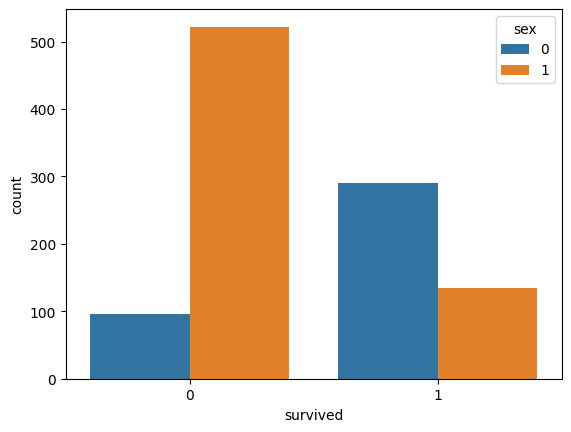

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='survived', hue='sex', data=df)
plt.show()

Aqui podemos verificar que existe una relacion entre la variable dependiente que es la sobrevivencia y la variable independiente que es el sexo de la persona, ya que en este caso vemos que las mujeres presentar mayor tasa de sobrevivencia esto debido al ser prioridad salvar a la mujeres y niños.

5. **Prueba t-test:** Esta puede ayudarte a entender si las diferencias en las medias de dos grupos son estadísticamente significativas.

In [45]:
from scipy.stats import ttest_ind

grupo1 = df[df['survived'] == 1]['age']
grupo2 = df[df['survived'] == 0]['age']

t_stat, p_val = ttest_ind(grupo1, grupo2)

print("p-value:", p_val)

p-value: 0.0638006823586831


El valor p obtenido fue de 0.0638, lo cual es mayor a 0.05, entonces, esto indica que no existe una diferencia estadisticamente significativa entre los grupos analizados, esto quiere decir que, la variable edad no tiene un impacto claro en la supervivencia de los pasajeros

6. **División de datos:** Divide los datos en variables de prueba y de entrenamiento. Esto es crucial para entrenar el modelo y luego evaluar su capacidad para generalizar a nuevos datos.

In [46]:
from sklearn.model_selection import train_test_split

X = df[['pclass', 'sex', 'age', 'fare']]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Se divivdieron los datos en conjunto de entrenamineto y prueba, donde el 80% se utilizó para entrenar el modelo y el 20% para evaluarlo, esto nos permite comprobar la capacidad del modelo para generalizar a nuevos dato.

7. **Creación del modelo:** Utiliza las clases vistas en la explicación de los temas para que puedas crear tu modelo.

In [47]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression()
modelo.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Este modelo permite predecir la probabilidad de sobrevivencia de los pasajeros en funcion de variables como el sexo, la edad, la clase y la tarfia.

8. **Estimación de los coeficientes y los odds ratio:** Una vez que entrenaste el modelo, el siguiente paso es interpretar los resultados. Esto se hace mediante la estimación de los coeficientes, los cuales te indicarán la fuerza y dirección de la relación entre cada variable independiente y la variable dependiente.

In [49]:
import numpy as np

coef = modelo.coef_[0]

for i, col in enumerate(X.columns):
    print(col, "Coeficiente:", coef[i])

pclass Coeficiente: -1.1672945326328712
sex Coeficiente: -2.4788349989640075
age Coeficiente: -0.036396598483123946
fare Coeficiente: 0.000591431608940574


In [50]:
odds_ratio = np.exp(coef)

for i, col in enumerate(X.columns):
    print(col, "Odds Ratio:", odds_ratio[i])

pclass Odds Ratio: 0.31120776579570675
sex Odds Ratio: 0.08384084338814413
age Odds Ratio: 0.9642577944602472
fare Odds Ratio: 1.0005916065390994


Como podemos ver los resultados del modelo nos muestran que la clase y el sexo son las variables más influyentes, siendo las mujeres y pasajeros de clases altas los que tienen mayor probabilidad de sobrevirir.

9. **Conclusión de tus resultados:** Formula una conclusión sobre tus hallazgos. Considera cuáles variables tienen mayor impacto en la probabilidad de sobrevivencia en el Titanic y la efectividad general de tu modelo para predecir la sobrevivencia. Reflexiona sobre posibles mejoras o ajustes para el modelo.

El modelo de regresión logística permitió identificar que las variables con mayor impacto en la sobrevivencia fueron el sexo y la clase del pasajero, observándose que las mujeres y los pasajeros de clases más altas tenían mayor probabilidad de sobrevivir. Por otro lado, variables como la edad y la tarifa tuvieron un impacto menor.